<a href="https://colab.research.google.com/github/Anshu-kumar-singh/Stock_price_trend_predication/blob/main/stock_price_trend_predication%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[*********************100%***********************]  1 of 1 completed


Logistic Regression Results
Accuracy: 0.5183946488294314
[[80 59]
 [85 75]]
              precision    recall  f1-score   support

           0       0.48      0.58      0.53       139
           1       0.56      0.47      0.51       160

    accuracy                           0.52       299
   macro avg       0.52      0.52      0.52       299
weighted avg       0.52      0.52      0.52       299


Random Forest Results
Accuracy: 0.5083612040133779
[[107  32]
 [115  45]]
              precision    recall  f1-score   support

           0       0.48      0.77      0.59       139
           1       0.58      0.28      0.38       160

    accuracy                           0.51       299
   macro avg       0.53      0.53      0.49       299
weighted avg       0.54      0.51      0.48       299



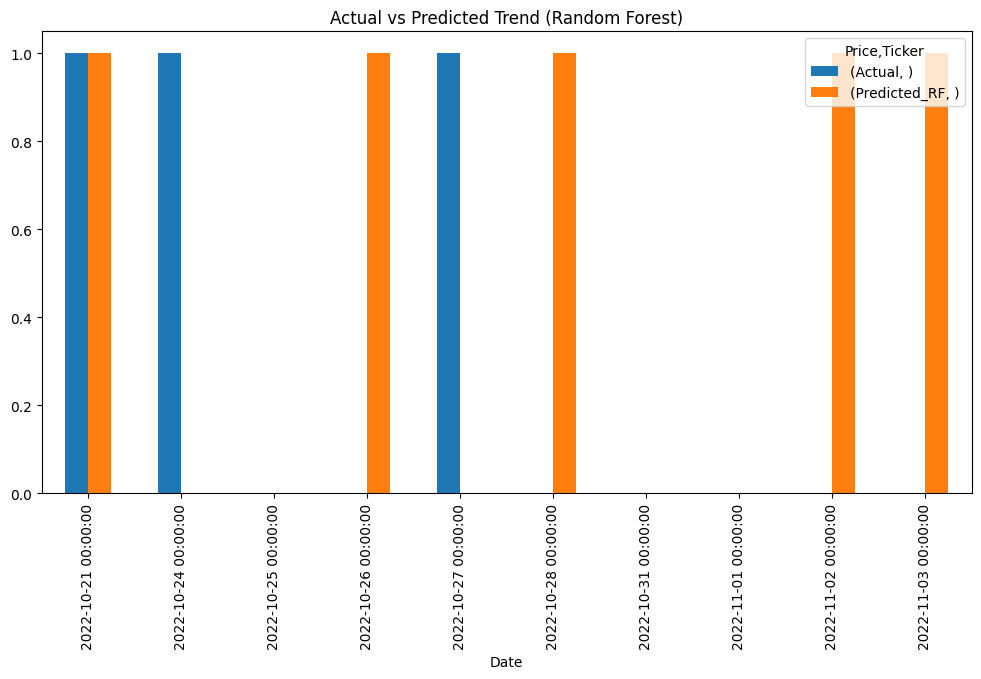

In [ ]:
# Stock Price Trend Prediction using Machine Learning

# Predict whether the stock price will go up or down tomorrow

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Download stock data
data = yf.download('AAPL', start='2018-01-01', end='2024-01-01')  # Apple stock

# Feature Engineering
data['Price_change'] = data['Close'].diff(1)

# Target: 1 = price up, 0 = down
data['Target'] = np.where(data['Price_change'].shift(-1) > 0, 1, 0)

# Create moving average features
data['SMA_5'] = data['Close'].rolling(window=5).mean()
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['SMA_15'] = data['Close'].rolling(window=15).mean()

# Drop NaN values
data.dropna(inplace=True)

# Select features and target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_5', 'SMA_10', 'SMA_15']

X = data[features]
y = data['Target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Random Forest doesn't need scaling

# Evaluate Logistic Regression
y_pred_log = log_reg.predict(X_test_scaled)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

# Evaluate Random Forest
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Plot actual vs predicted
data_test = X_test.copy()

data_test['Actual'] = y_test
data_test['Predicted_RF'] = y_pred_rf

data_test[['Actual', 'Predicted_RF']].head(10).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title("Actual vs Predicted Trend (Random Forest)")
plt.show()